# Compare results from UPM and WSP for ...
1. GO terms
2. Genes
3. tREs

In [3]:
library(data.table)
library(stringr)
library(UpSetR)
library(ggplot2)
library(clusterProfiler)
library(org.Hs.eg.db)
library(grid)
library(gridExtra)

## GO terms

In [4]:

get_GO_terms <- function(file_name) {
    
    go_df <- fread(file_name)
    go_terms = unique(go_df$Description)
    return(go_terms)
    }

In [9]:
# read in the GO terms 
options(warn=-1)

EFP_UPM <- get_GO_terms("../results/GO/p1e10_GO_EarlyFallPlatUPM_DESeq2_GeneHK.txt")
ERP_UPM <- get_GO_terms("../results/GO/p1e10_GO_EarlyRisePlatUPM_DESeq2_GeneHK.txt")
EFP_WSP <- get_GO_terms("../results/GO/p1e10_GO_EarlyFallPlatWSP_DESeq2_GeneHK.txt")
ERP_WSP <- get_GO_terms("../results/GO/p1e10_GO_EarlyRisePlatWSP_DESeq2_GeneHK.txt")

EF_UPM <- get_GO_terms("../results/GO/p1e10_GO_EarlyFallUPM_DESeq2_GeneHK.txt")
EF_WSP <- get_GO_terms("../results/GO/p1e10_GO_EarlyFallWSP_DESeq2_GeneHK.txt")
ER_UPM <- get_GO_terms("../results/GO/p1e10_GO_EarlyRiseUPM_DESeq2_GeneHK.txt")
ER_WSP <- get_GO_terms("../results/GO/p1e10_GO_EarlyRiseWSP_DESeq2_GeneHK.txt")

LF_UPM <- get_GO_terms("../results/GO/p1e10_GO_LateFallUPM_DESeq2_GeneHK.txt")
LF_WSP <- get_GO_terms("../results/GO/p1e10_GO_LateFallWSP_DESeq2_GeneHK.txt")
LR_UPM <- get_GO_terms("../results/GO/p1e10_GO_LateRiseUPM_DESeq2_GeneHK.txt")
LR_WSP <- get_GO_terms("../results/GO/p1e10_GO_LateRiseWSP_DESeq2_GeneHK.txt")
options(warn=1)


Early Rise Plateau both UPM and WSP: gland development
Early Fall Plateau both UPM and WSP: regulation of axonogenesis
Early Plateau Rise WSP but Fall UPM: developmental cell growth; developmental growth involved in morphogenesis

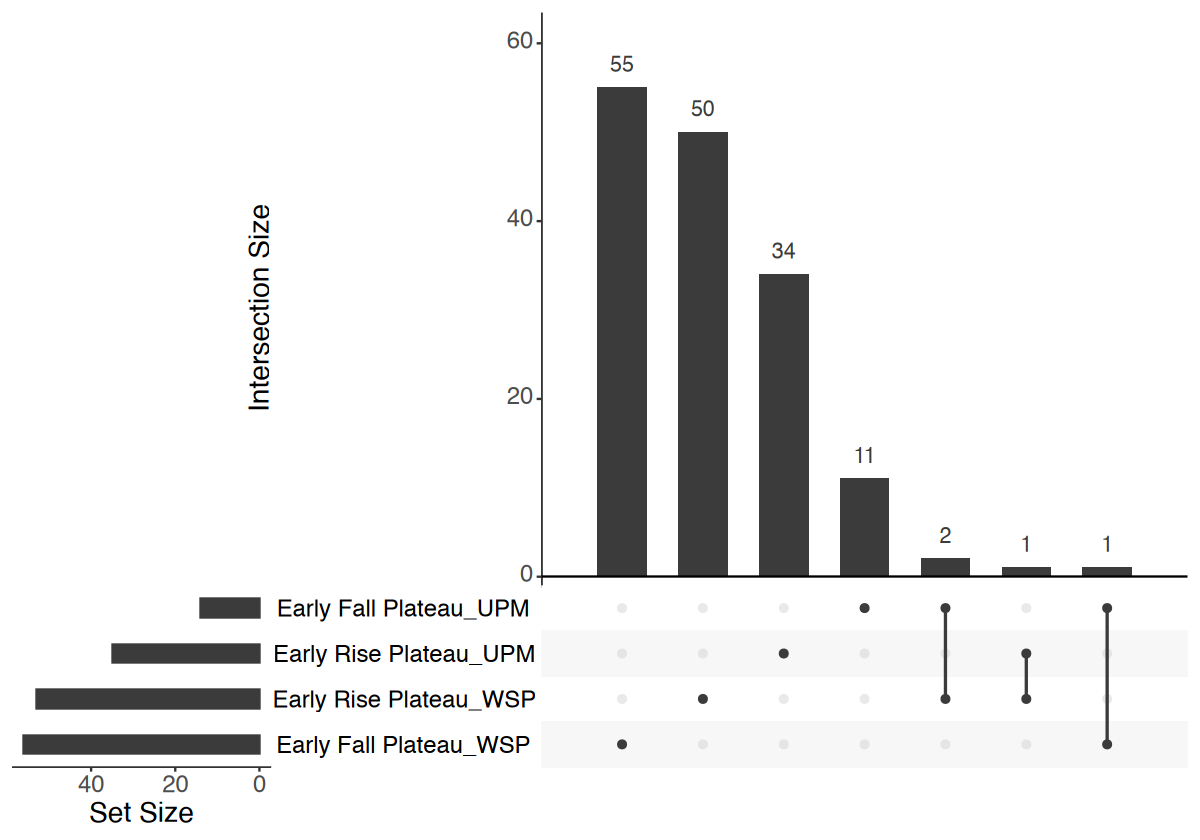

In [15]:
Plateau <- list("Early Fall Plateau_UPM"=EFP_UPM, "Early Rise Plateau_UPM"=ERP_UPM, 
              "Early Fall Plateau_WSP"=EFP_WSP, "Early Rise Plateau_WSP"=ERP_WSP)
options(repr.plot.width=10)
upset(fromList(Plateau), nsets=4, text.scale=2)
cat("\nEarly Rise Plateau both UPM and WSP:", intersect(ERP_UPM, ERP_WSP))

cat("\nEarly Fall Plateau both UPM and WSP:", intersect(EFP_UPM, EFP_WSP))

cat("\nEarly Plateau Rise WSP but Fall UPM:", paste(intersect(EFP_UPM, ERP_WSP), collapse="; "))


Early Fall for both:

character(0)


Early Rise for both:

[1] "regulation of actin filament-based process"             
 [2] "actin filament organization"                            
 [3] "regulation of actin cytoskeleton organization"          
 [4] "positive regulation of cell adhesion"                   
 [5] "positive regulation of leukocyte activation"            
 [6] "positive regulation of cell activation"                 
 [7] "establishment or maintenance of cell polarity"          
 [8] "regulation of focal adhesion assembly"                  
 [9] "regulation of cell-substrate junction assembly"         
[10] "positive regulation of lymphocyte activation"           
[11] "regulation of cell junction assembly"                   
[12] "cell-substrate junction assembly"                       
[13] "positive regulation of leukocyte cell-cell adhesion"    
[14] "cell-substrate junction organization"                   
[15] "focal adhesion assembly"                                
[16] "positive regulation of cell-cell adhesion"              
[17] "positive regulation of T cell activation"               
[18] "cell junction assembly"                                 
[19] "regulation of cell-cell adhesion"                       
[20] "cell-cell junction organization"                        
[21] "positive regulation of lymphocyte differentiation"      
[22] "positive regulation of leukocyte differentiation"       
[23] "positive regulation of hemopoiesis"                     
[24] "positive regulation of T cell differentiation"          
[25] "establishment of cell polarity"                         
[26] "regulation of T cell activation"                        
[27] "small GTPase-mediated signal transduction"              
[28] "rhythmic process"                                       
[29] "response to type II interferon"                         
[30] "regulation of small GTPase mediated signal transduction"
[31] "mononuclear cell differentiation"                       
[32] "circadian rhythm"                                       
[33] "cellular response to peptide hormone stimulus"          
[34] "CD4-positive, alpha-beta T cell activation"             
[35] "response to peptide hormone"                            
[36] "CD4-positive, alpha-beta T cell differentiation"        
[37] "alpha-beta T cell differentiation"                      
[38] "focal adhesion"                                         
[39] "cell-substrate junction"                                
[40] "cell cortex"                                            
[41] "actin filament bundle"                                  
[42] "cell leading edge"                                      
[43] "stress fiber"                                           
[44] "contractile actin filament bundle"                      
[45] "actomyosin"                                             
[46] "cortical cytoskeleton"                                  
[47] "lamellipodium"                                          
[48] "cortical actin cytoskeleton"                            
[49] "I band"                                                 
[50] "Z disc"                                                 
[51] "clathrin-coated endocytic vesicle"                      
[52] "apical part of cell"                                    
[53] "clathrin-coated vesicle"                                
[54] "adherens junction"                                      
[55] "actin binding"


Early Fall WSP but Rise for UPM:

[1] "cilium organization"     "cilium assembly"        
[3] "ciliary transition zone" "ciliary basal body"


Early Rise WSP but Fall for UPM:

[1] "actin filament organization"                           
 [2] "regulation of actin cytoskeleton organization"         
 [3] "actin filament bundle assembly"                        
 [4] "actin filament bundle organization"                    
 [5] "positive regulation of cell adhesion"                  
 [6] "regulation of cell-substrate adhesion"                 
 [7] "small GTPase-mediated signal transduction"             
 [8] "positive regulation of cell projection organization"   
 [9] "positive regulation of cell development"               
[10] "establishment of epithelial cell apical/basal polarity"
[11] "tissue remodeling"                                     
[12] "positive regulation of cell-substrate adhesion"        
[13] "focal adhesion"                                        
[14] "cell-substrate junction"                               
[15] "cell leading edge"                                     
[16] "cadherin binding"

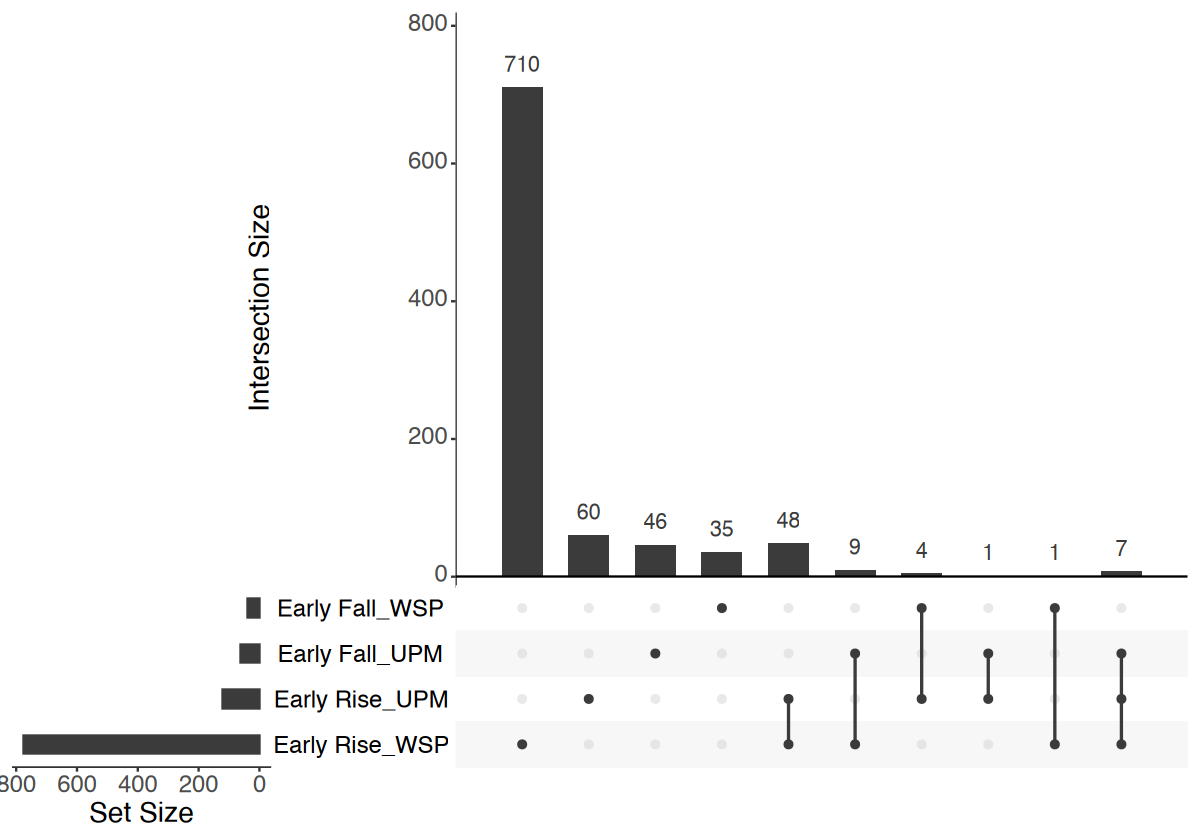

In [16]:
Early <- list("Early Fall_UPM"=EF_UPM, "Early Rise_UPM"=ER_UPM, 
              "Early Fall_WSP"=EF_WSP, "Early Rise_WSP"=ER_WSP)
options(repr.plot.width=10)
upset(fromList(Early), nsets=4, text.scale=2)
cat("\nEarly Fall for both:")
intersect(EF_WSP, EF_UPM)
cat("\nEarly Rise for both:")
intersect(ER_WSP, ER_UPM)
cat("\nEarly Fall WSP but Rise for UPM:")
intersect(EF_WSP, ER_UPM)
cat("\nEarly Rise WSP but Fall for UPM:")
intersect(ER_WSP, EF_UPM)

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


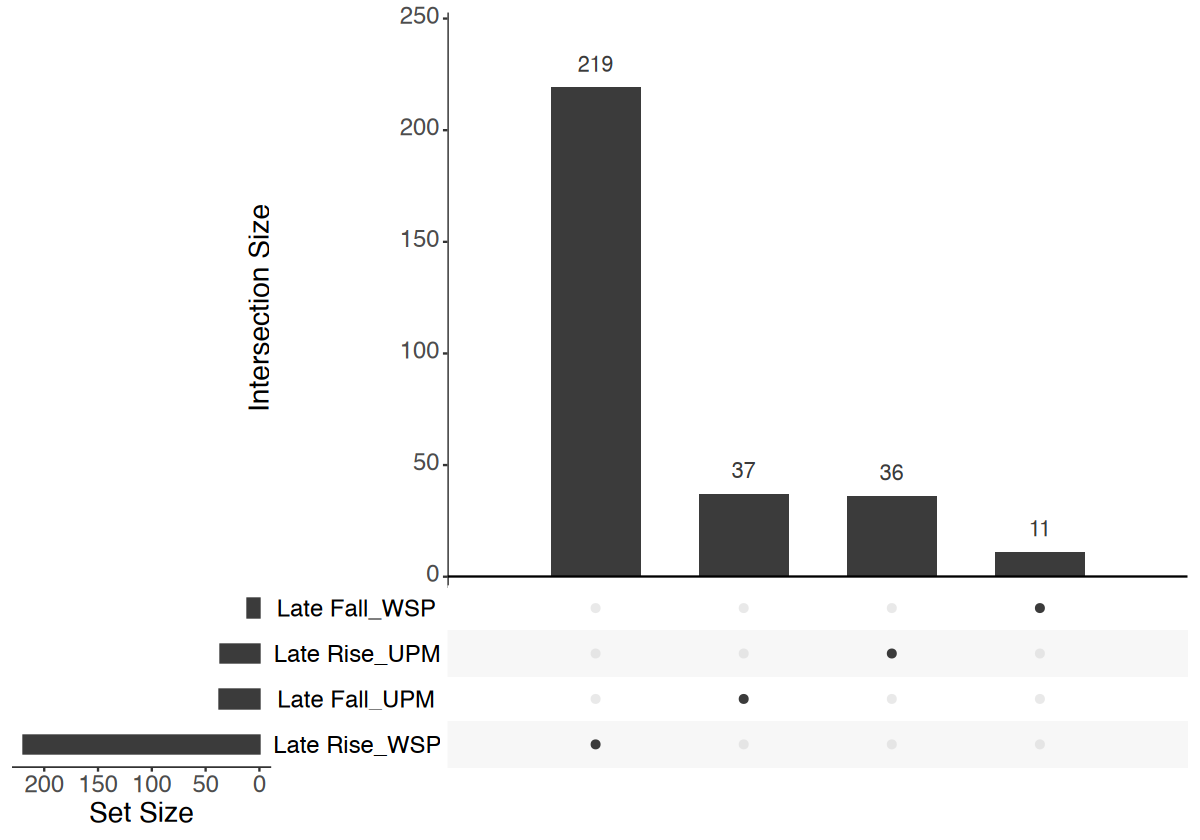

In [18]:
Late <- list("Late Fall_UPM"=LF_UPM, "Late Rise_UPM"=LR_UPM, 
              "Late Fall_WSP"=LF_WSP, "Late Rise_WSP"=LR_WSP)
options(repr.plot.width=10)
upset(fromList(Late), nsets=4, text.scale=2)

## Genes

In [19]:
# read in significant gene calls
UPM_sig <- readRDS("../results/UPM_siggenes_DESeq2_GeneHK_p1e10.rds")
names(UPM_sig)
WSP_sig <- readRDS("../results/WSP_siggenes_DESeq2_GeneHK_p1e10.rds")
names(WSP_sig)

[1] "P120_vs_Veh_up"   "P30_vs_Veh_up"    "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "P30_vs_Veh_down"  "P120_vs_P30_down"

[1] "P120_vs_Veh_up"   "P30_vs_Veh_up"    "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "P30_vs_Veh_down"  "P120_vs_P30_down"

### General

[1] "WSPP120_vs_Veh_up"   "WSPP30_vs_Veh_up"    "WSPP120_vs_P30_up"  
 [4] "WSPP120_vs_Veh_down" "WSPP30_vs_Veh_down"  "WSPP120_vs_P30_down"
 [7] "UPMP120_vs_Veh_up"   "UPMP30_vs_Veh_up"    "UPMP120_vs_P30_up"  
[10] "UPMP120_vs_Veh_down" "UPMP30_vs_Veh_down"  "UPMP120_vs_P30_down"

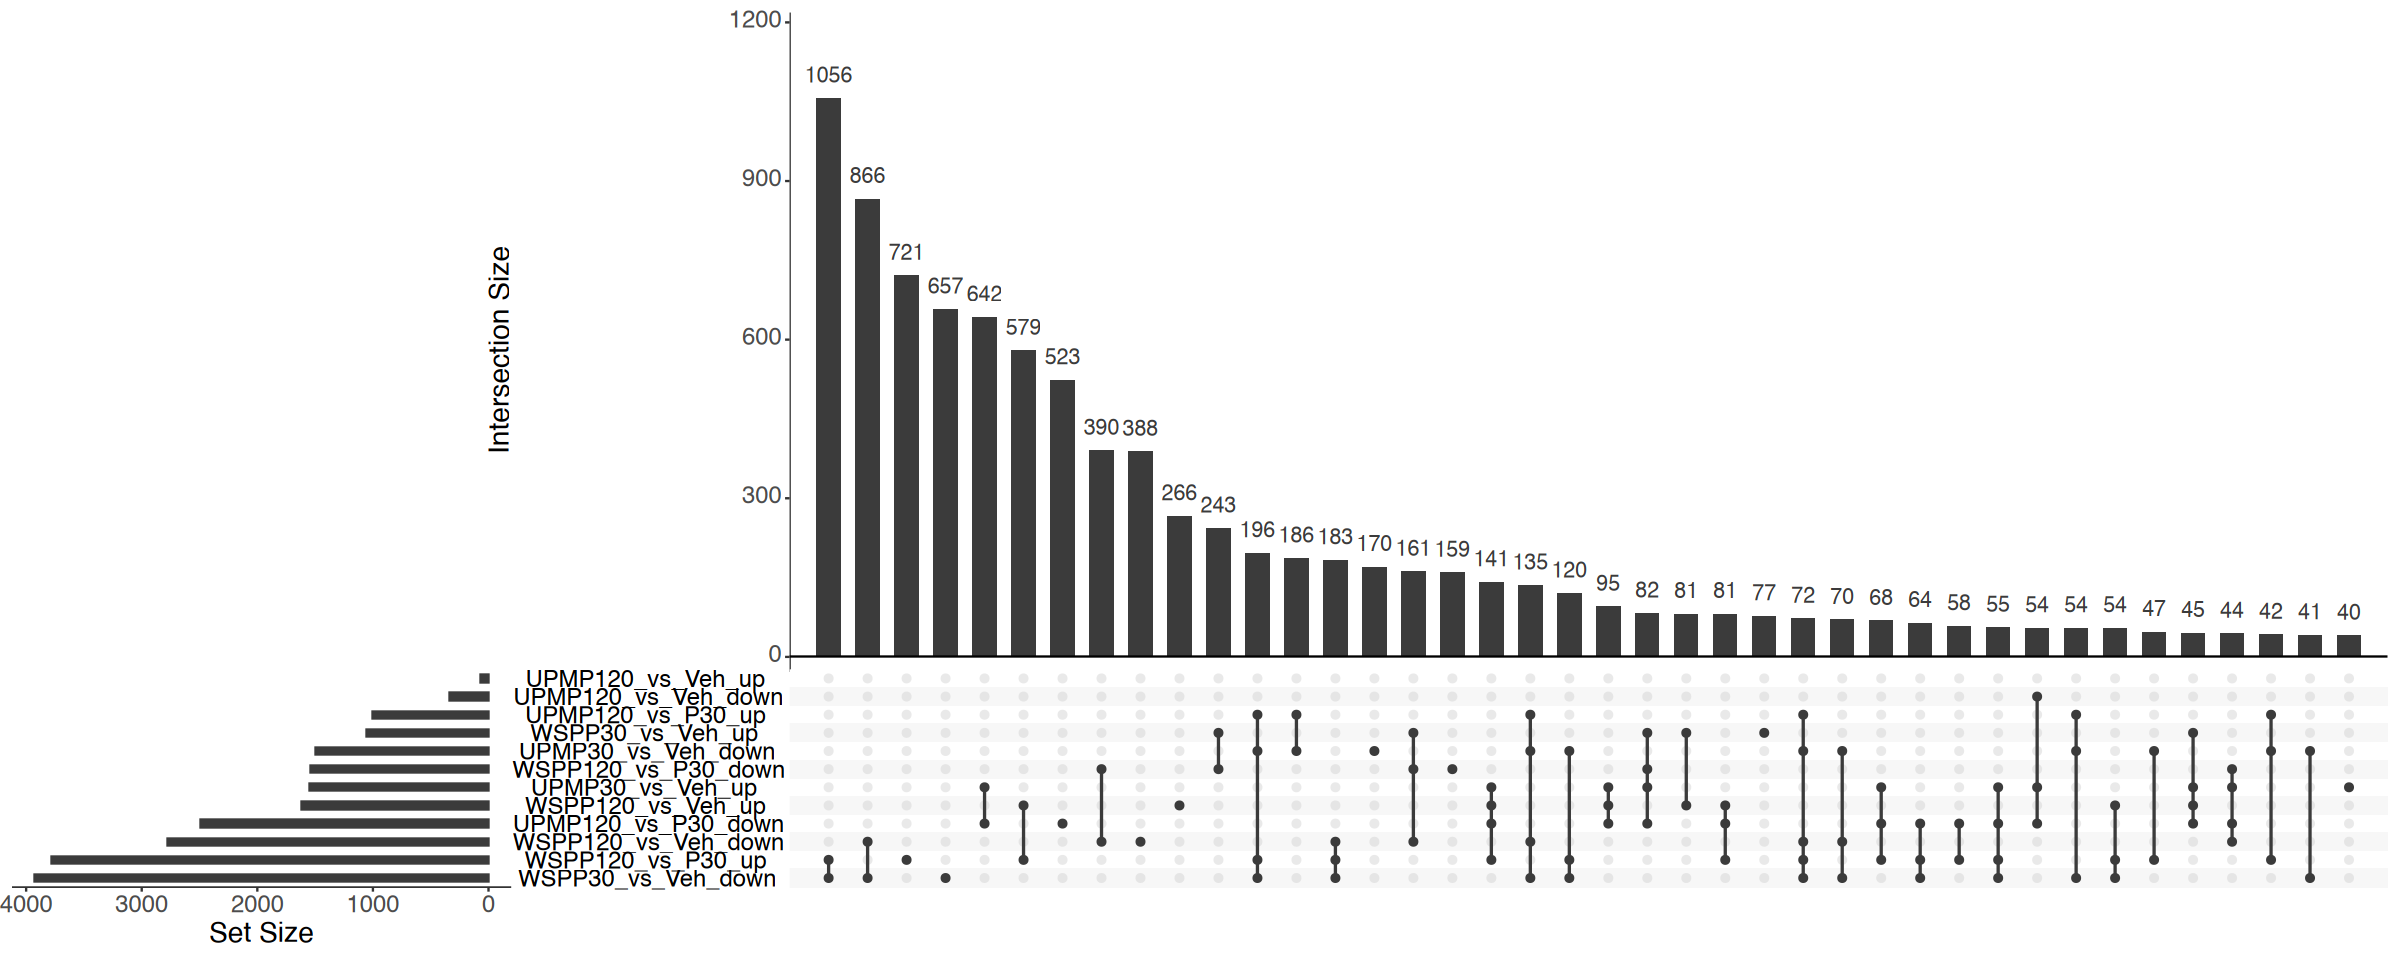

In [61]:
plot_UPM_sig = UPM_sig
names(plot_UPM_sig) <- paste0("UPM", names(plot_UPM_sig))
plot_WSP_sig = WSP_sig
names(plot_WSP_sig) <- paste0("WSP", names(plot_WSP_sig))

plot_sig = c(plot_WSP_sig, plot_UPM_sig)
names(plot_sig)
options(repr.plot.height=8, repr.plot.width=20)
upset(fromList(plot_sig), nsets=12, text.scale=2, order.by="freq")

* WSP120 > WSP30 & WSP30 < Veh: 1,056 (EARLY DOWN WSP)
* WSP120 < Veh & WSP30 < Veh: 866 (EARLY DOWN PLATEAU WSP)
* UPM30 > Veh & UPM120 < UPM30: 642 (EARLY UP UPM)
* WSP120 > WSP30 & WSP30 < Veh (Early Down WSP) and UPM30 < Veh & UPM120 > UPM30 (Early down UPM): 196 EARLY DOWN BOTH
* WSP120 > WSP30 & WSP120 > Veh (Late Up)  & UPM120 < UPM30 & UPM30 > Veh (Early Up): 141 Late Up in WSP but Early Up in UPM
* WSP30 < Veh & WSP120 < Veh (EP Down) & UPM30 < Veh UPM120 > UPM30 (Early Down): 135 EP Down in WSP but Early Down in UPM
* UPM120 < UPM30 & UPM30 > Veh (Early Up) & WSP120 < WSP30 & WSP30 > Veh (Early Up): 82 Early Up in Both
* UPM120 > UPM30 & UPM30 < Veh (Early Down) WSP120 < Veh & WSP120 > WSP30 & WSP30 < Veh (Down-Up-Overall Down): 72
* UPM30 > Veh & UPM120 < UPM30 (Early Up) & WSP120>WSP30 & WSP30 < Veh (Early Down): 55
* WSP30 > Veh & WSP120 > Veh (EP Up) & UPM120 < UPM30 & UPM30 > Veh (Early Rise): 45
* WSP120 < Veh & WSP120 < WSP30 (Late Down) & UPM120 < UPM30 & UPM30 > Veh (Early Rise): 44

### Timing

In [20]:
## EARLY and Temporary
get_timing_sig <- function(sig_feat) {
    # up at 30min and down by 120. Not significant for 120 vs Veh
    early_rise = setdiff(intersect(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # down at 30min and up by 120. Not significant for 120 vs Veh
    early_fall = setdiff(intersect(sig_feat[["P30_vs_Veh_down"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # up 120min and 30min, with no change between 120 & 30min
    plat_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P30_vs_Veh_up"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # down 120min and 30min, with no change between 120 & 30min
    plat_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P30_vs_Veh_down"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # up at 120min compared to Veh and 30min. Not sig at 30min
    late_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    # down at 120min compared to Veh and 30min. Not sig at 30min
    late_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    time_sig <- list("ER"=early_rise, "EF"=early_fall, "EPR"=plat_rise, "EPF"=plat_fall, 
                     "LR"=late_rise, "LF"=late_fall)
    return(time_sig)
    }
UPM_time_sig = get_timing_sig(UPM_sig)
WSP_time_sig = get_timing_sig(WSP_sig)

In [21]:
run_go_analysis <- function(gene_symbols) {
    # gene_ids <- bitr(gene_symbols, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
    # # Extract the Entrez IDs
    # entrez_gene_list <- gene_ids$ENTREZID
    # GO enrichment analysis
    go_enrichment <- enrichGO(gene = gene_symbols,
                          OrgDb = org.Hs.eg.db,
                          keyType = "SYMBOL",
                          ont = "ALL",  # Can be "BP", "MF", or "CC" for specific ontology categories
                          pAdjustMethod = "BH",
                          pvalueCutoff = 0.05,
                          qvalueCutoff = 0.05)

    return(go_enrichment)
    }

Early Fall Plateau Both PPARD; NECAB3; LOC100130987; LOC101926889; CTDSP1; TMEM51; SLC39A1
Early Plateau Rise in UPM and Fall in WSP SPIRE2; KSR1; OSBPL10

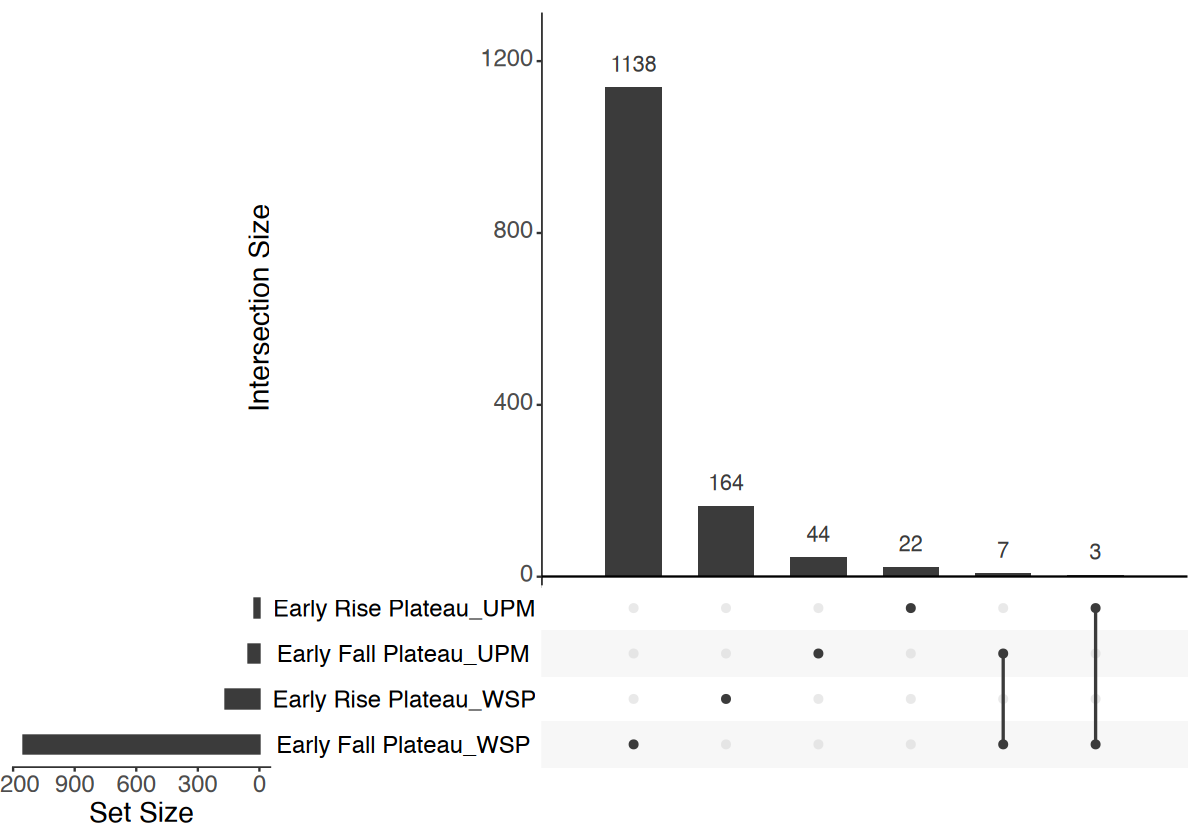

In [25]:
Plateau <- list("Early Fall Plateau_UPM"=UPM_time_sig$EPF, "Early Rise Plateau_UPM"=UPM_time_sig$EPR, 
              "Early Fall Plateau_WSP"=WSP_time_sig$EPF, "Early Rise Plateau_WSP"=WSP_time_sig$EPR)
options(repr.plot.width=10)
upset(fromList(Plateau), nsets=4, text.scale=2)

EFP_both = intersect(UPM_time_sig$EPF, WSP_time_sig$EPF) # 7
ERPU_EFPW = intersect(UPM_time_sig$EPR, WSP_time_sig$EPF) # 3

cat("Early Fall Plateau Both:", paste(EFP_both, collapse=", ")) # No GSEA overlaps found
cat("\nEarly Plateau Rise in UPM and Fall in WSP:", paste(ERPU_EFPW, collapse=", ")) # No GSEA overlaps found
GO_EFP_both = run_go_analysis(EFP_both)
GO_ERPU_EFPW = run_go_analysis(ERPU_EFPW)

Early Rise Both (82): LMCD1, PDLIM5, VCL, NCOA7, NFE2L2, PALLD, GRAMD2B, OSMR, ARID5B, STK24, NEDD9, PLS3, IL18, NAMPT, TLE1, KIAA1217, NR1D2, SCHIP1, SMAP2, SLC7A1, SEPTIN10, MIR4435-2HG, PHACTR2, ETS2, CORO1C, TGFB2, CAB39, KANK4, TGFBI, VPS37B, ATP2B1, NEDD4, VGLL3, ARF4, TUFT1, TMBIM6, ANXA3, IGFBP7, GBP2, BBOF1, MSI2, GCH1, CALD1, ODC1, FLRT2, CREB5, ABL2, IBA57, AOPEP, IRS2, PTPN14, PDP1, MBNL1, ATP2A2, RAB9A, YWHAZ, MALT1, ANKRD28, CCN2, PTPN11, DCLRE1C, CTIF, STX12, RUFY1-AS1, FGF5, MYL12A, LINC-PINT, GTPBP4, AFG3L2, MAPRE1, KLF7, WEE1, GLIPR1, SFT2D1, EIF1, LPIN1, ZNF860, WWTR1, UBIAD1, SPRED2, PNMA1, RHOA

Early Fall Both (196): MPZL1, HLA-F-AS1, SLC9A7, DEXI, SOX13, LOC105373064, LINC02210-CRHR1, LINC02210, MPI, BAZ2A, SDC1, SYT12, SLC35F2, GID4, ZNF343, PLEKHA8, MIR570HG, PAQR5, IRF5, TTC13, LIFR, AIDA, ZBTB46, SH3YL1, PYGL, MTSS1, ZNF436, FBXO9, BPNT1, IARS2, HDAC11, PPIC, ANKRD16, CASS4, MXI1, NAPB, ACSS2, EEIG1, XPO5, ZNF514, PAFAH2, ARL10, BCL7C, NDUFA8, ZNF862, SETD3, 

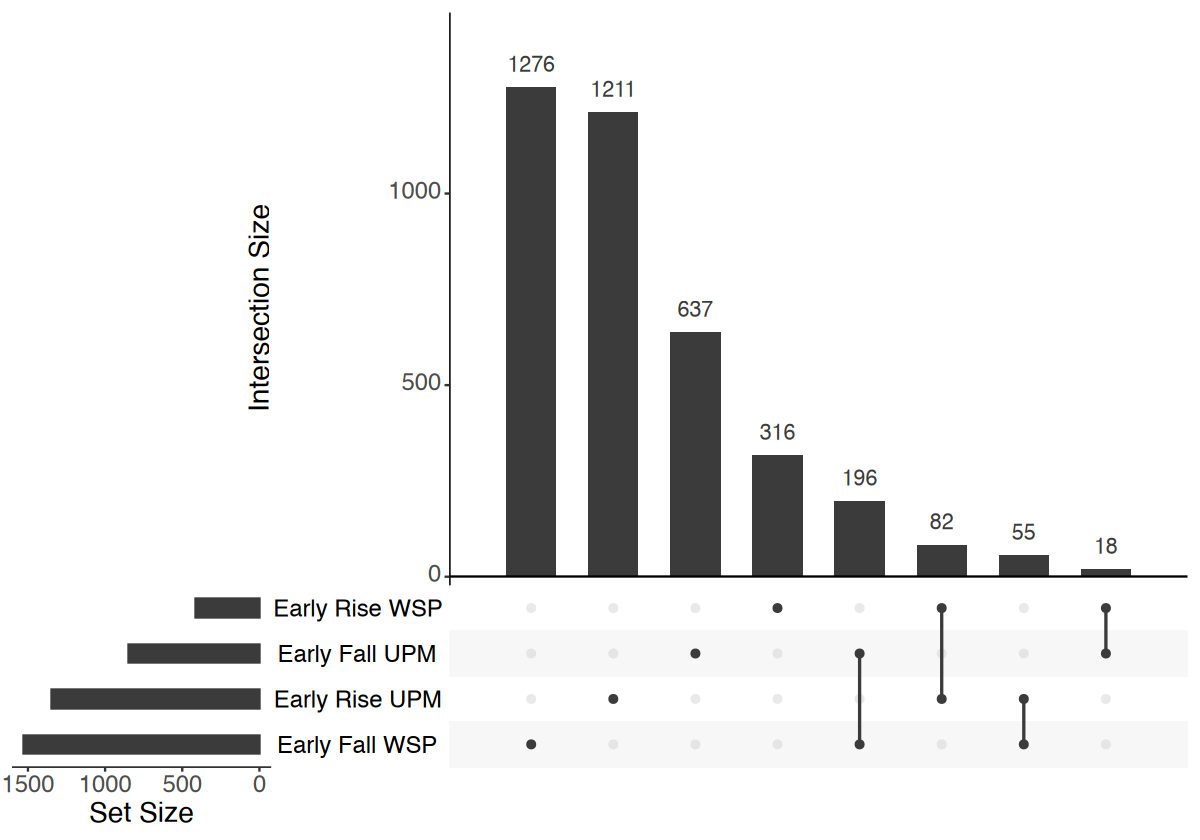

In [29]:
Early <- list("Early Fall UPM"=UPM_time_sig$EF, "Early Rise UPM"=UPM_time_sig$ER, 
              "Early Fall WSP"=WSP_time_sig$EF, "Early Rise WSP"=WSP_time_sig$ER)
options(repr.plot.width=10)
upset(fromList(Early), nsets=4, text.scale=2)

ER_both = intersect(UPM_time_sig$ER, WSP_time_sig$ER) # 82
EF_both = intersect(UPM_time_sig$EF, WSP_time_sig$EF) # 196

ERU_EFW = intersect(UPM_time_sig$ER, WSP_time_sig$EF) # 55 UPM early rise but WSP early fall
EFU_ERW = intersect(UPM_time_sig$EF, WSP_time_sig$ER) # 18 UPM early fall but WSP early rise

cat("Early Rise Both (82):", paste(ER_both, collapse=", "))
cat("\n\nEarly Fall Both (196):", paste(EF_both, collapse=", "))

cat("\n\nEarly Rise UPM but Fall WSP (55):", paste(ERU_EFW, collapse=", "))
cat("\n\nEarly Fall UPM but Rise WSP (55):", paste(EFU_ERW, collapse=", "))
GO_ER_both = run_go_analysis(ER_both)
GO_EF_both = run_go_analysis(EF_both)
GO_ERU_EFW = run_go_analysis(ERU_EFW)
GO_EFU_ERW = run_go_analysis(EFU_ERW)


Genes Late Fall Both: P3R3URF-PIK3R3,PIK3R3,LOC128031837,OSGIN1

Genes Late Fall in UPM but Rise in WSP: PLEKHA7,COBL,ADAMTSL3

Genes Late Rise in UPM but Fall in WSP: TPCN1,DAPK1,AHRR,VIPR1

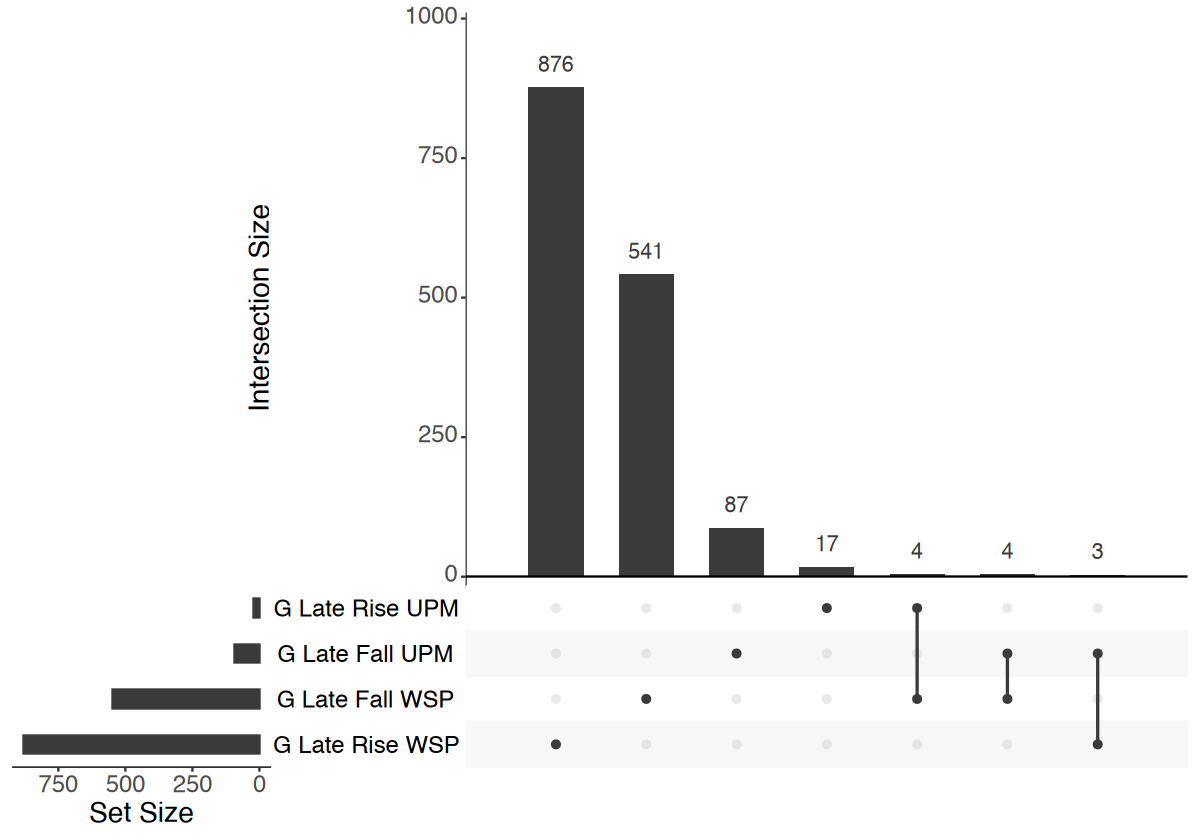

In [35]:
Late <- list("G Late Fall UPM"=UPM_time_sig$LF, "G Late Rise UPM"=UPM_time_sig$LR, 
              "G Late Fall WSP"=WSP_time_sig$LF, "G Late Rise WSP"=WSP_time_sig$LR)
options(repr.plot.width=10)
upset(fromList(Late), nsets=4, text.scale=2)

# cat("\nGenes Late Fall UPM but Rise WSP:", intersect(UPM_time_sig$LF, WSP_time_sig$LR))
LF_both = intersect(UPM_time_sig$LF, WSP_time_sig$LF) # 4
ULF_WLR = intersect(UPM_time_sig$LF, WSP_time_sig$LR) # 3
ULR_WLF = intersect(UPM_time_sig$LR, WSP_time_sig$LF) # 4

cat("\nGenes Late Fall Both:", paste0(LF_both, collapse=",")) # No significant GSEA terms
cat("\n\nGenes Late Fall in UPM but Rise in WSP:", paste0(ULF_WLR, collapse=",")) # No significant GSEA terms
cat("\n\nGenes Late Rise in UPM but Fall in WSP:", paste0(ULR_WLF, collapse=",")) # No significant GSEA terms

GO_LF_both = run_go_analysis(LF_both)
GO_ULF_WLR = run_go_analysis(ULF_WLR)
GO_ULR_WLF = run_go_analysis(ULR_WLF)

### Numbers of significantly enriched terms
* **Late:** Late Fall both: 4 genes & 46 enrichment terms
* **Late:** Late Fall in UPM but Rise in WSP: 3 genes & 59 enrichment terms
* **Late:** Late Rise in UPM but Rise in WSP: 3 genes & 25 enrichment terms

* **Early:** Early Rise both: 82 genes & 24 enrichment terms
* **Early:** Early Rise in UPM but Fall in WSP: 55 genes & 4 enrichment terms
* **Early:** Early Fall both: 196 genes & 0 enrichment terms
* **Early:** Early Rise in WSP but Fall in UPM: 18 genes & 9 enrichment terms

* **EPlateau:** Early Plateau Fall Both: 7 genes & 17 enrichment terms
* **EPlateau:** Early Plateau Rise in UPM but Fall in WSP: 3 genes & 17 enrichment terms

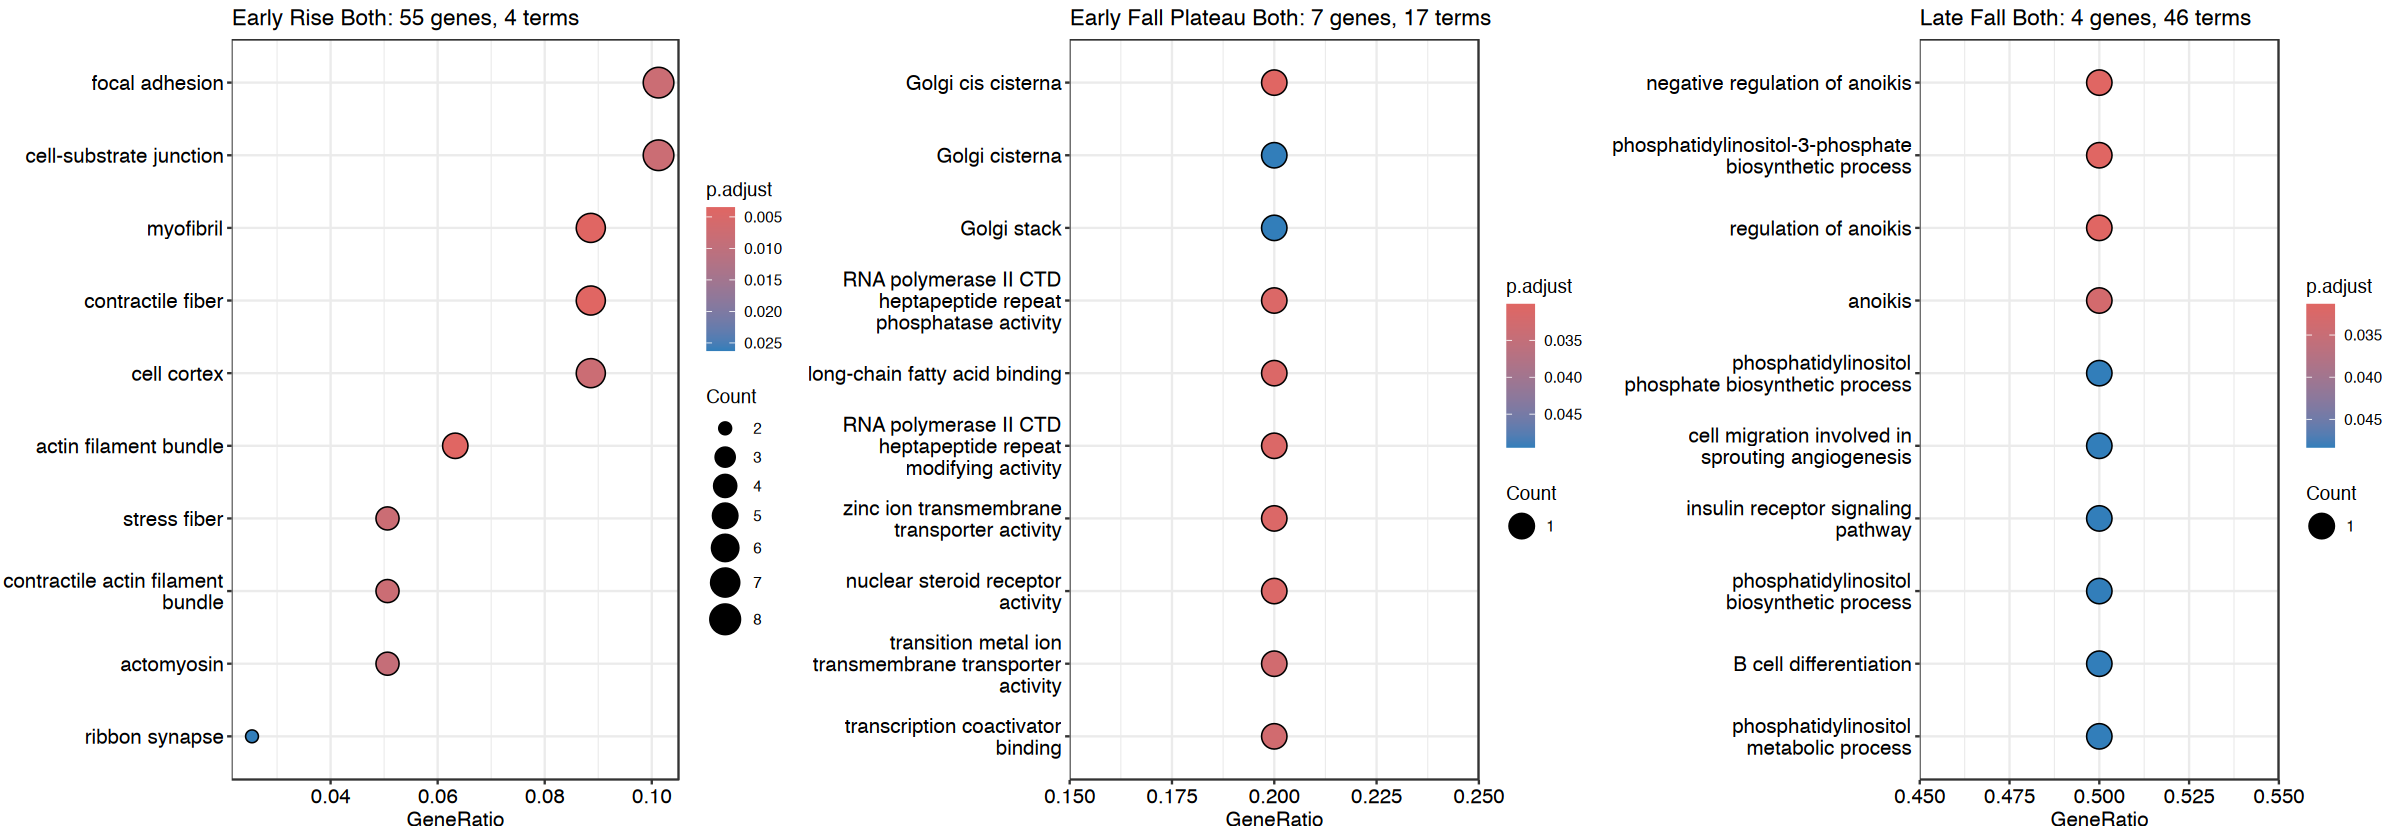

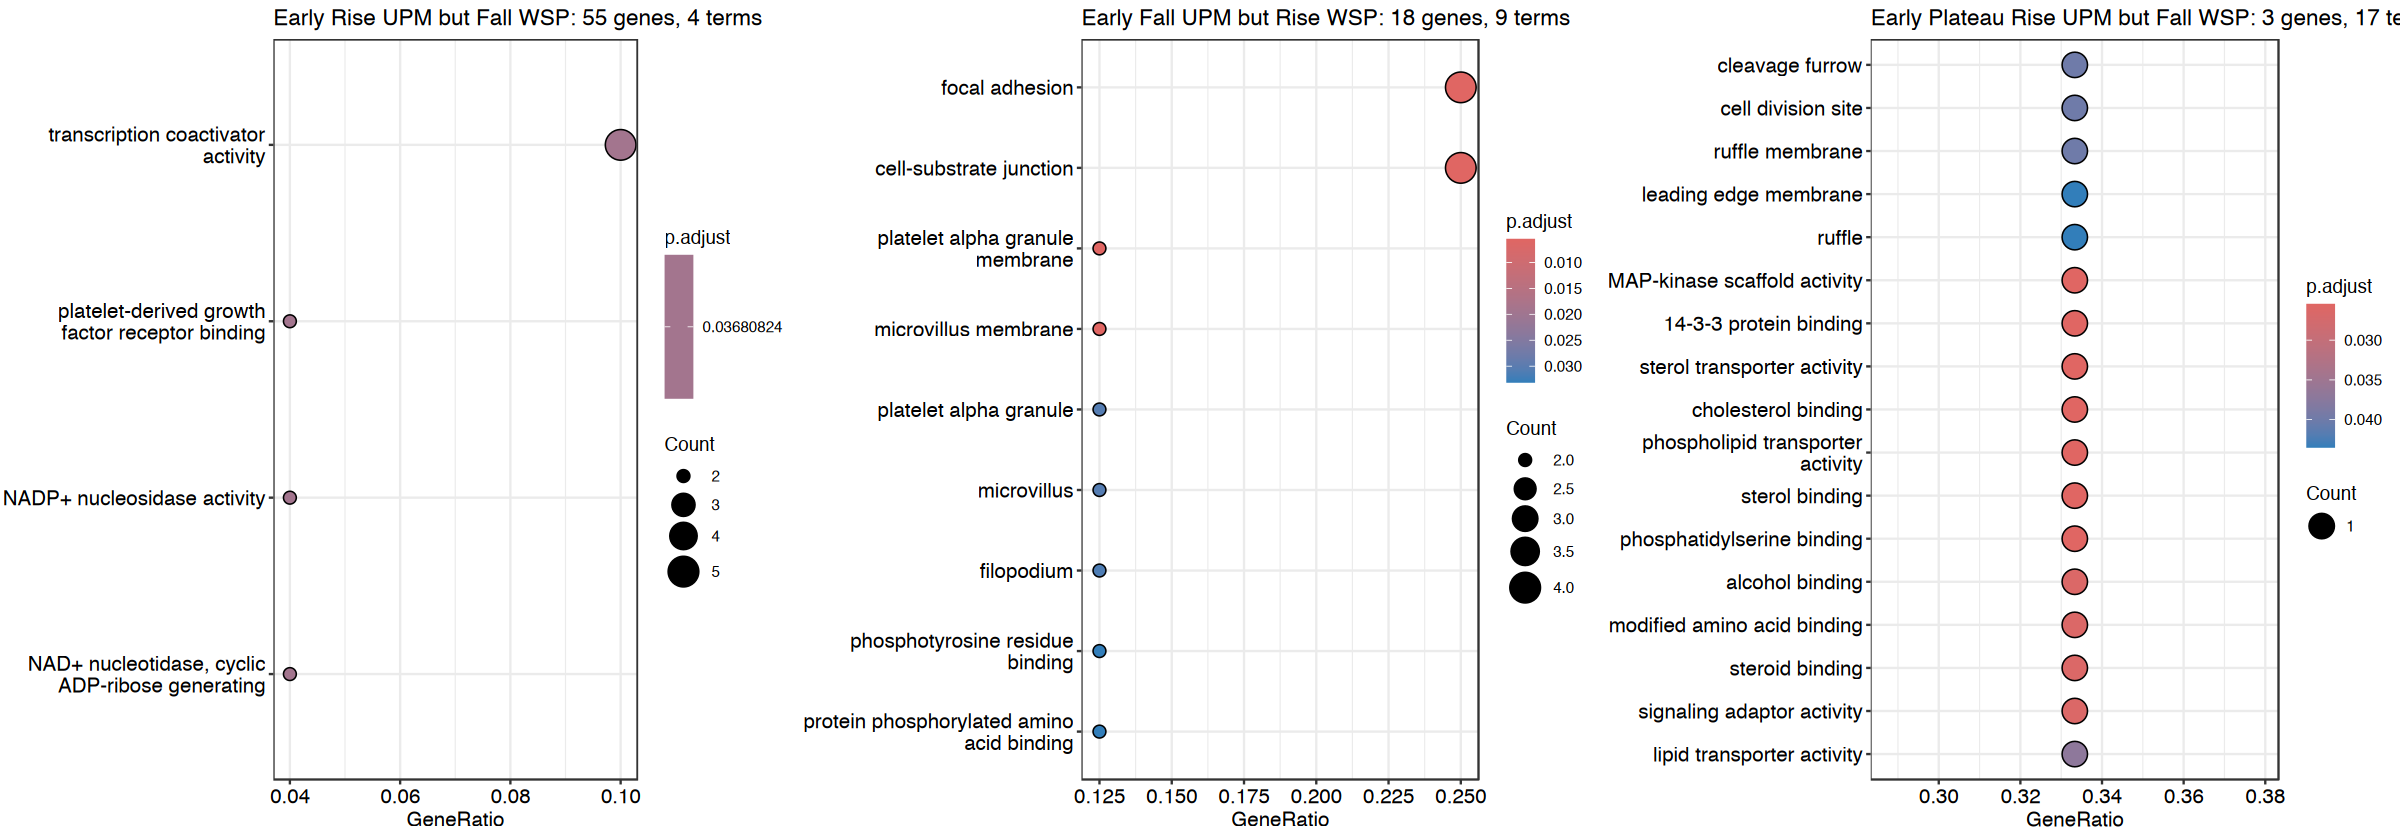

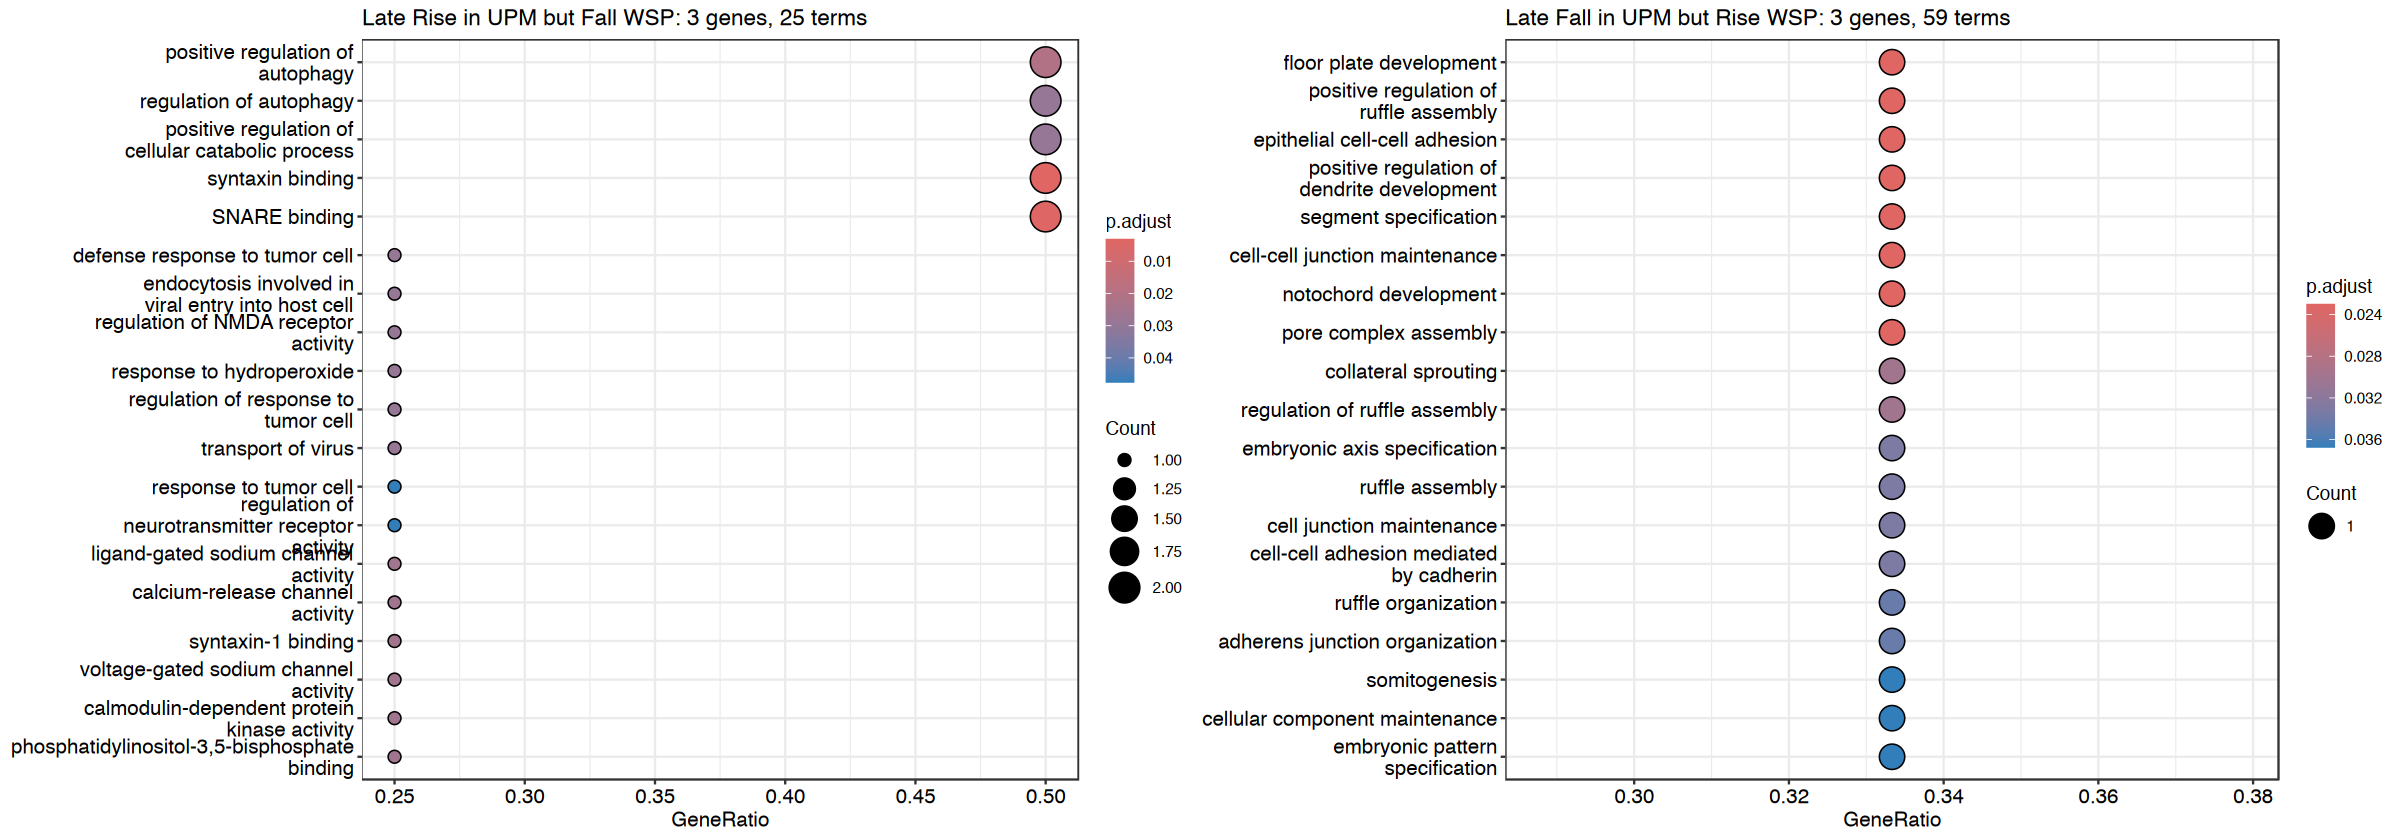

In [50]:
options(repr.plot.width=20)
p1 <- dotplot(GO_ER_both, showCategory = 10, title="Early Rise Both: 55 genes, 4 terms")
p2 <- dotplot(GO_EFP_both, showCategory = 10, title="Early Fall Plateau Both: 7 genes, 17 terms")
p3 <- dotplot(GO_LF_both, showCategory = 10, title="Late Fall Both: 4 genes, 46 terms")
grid.arrange(p1, p2, p3,  ncol = 3)

p1 <- dotplot(GO_ERU_EFW, showCategory = 10, title="Early Rise UPM but Fall WSP: 55 genes, 4 terms")
p2 <- dotplot(GO_EFU_ERW, showCategory = 10, title="Early Fall UPM but Rise WSP: 18 genes, 9 terms")
p3 <- dotplot(GO_ERPU_EFPW, showCategory = 19, title="Early Plateau Rise UPM but Fall WSP: 3 genes, 17 terms")
p4 <- dotplot(GO_ULR_WLF, showCategory = 19, title="Late Rise in UPM but Fall WSP: 3 genes, 25 terms")
p5 <- dotplot(GO_ULF_WLR, showCategory = 19, title="Late Fall in UPM but Rise WSP: 3 genes, 59 terms")

grid.arrange(p1, p2, p3,  ncol = 3)
grid.arrange(p4, p5,  ncol = 2)


In [74]:
# save GO results
write.table(GO_ER_both, paste0("../results/GO/GO_EarlyRise_BOTHWSPUPM_DESeq2_GeneHK_p001.txt"), 
           sep="\t", quote=FALSE)
write.table(GO_ERP_both, paste0("../results/GO/GO_EarlyRisePlat_BOTHWSPUPM_DESeq2_GeneHK_p001.txt"), 
           sep="\t", quote=FALSE)
write.table(GO_ERU_EFW, paste0("../results/GO/GO_ERU_EFW_DESeq2_GeneHK_p001.txt"), 
           sep="\t", quote=FALSE)
write.table(GO_EFU_ERW, paste0("../results/GO/GO_EFU_ERW_DESeq2_GeneHK_p001.txt"), 
           sep="\t", quote=FALSE)
write.table(GO_ERPU_EFPW, paste0("../results/GO/GO_ERPU_EFPW_DESeq2_GeneHK_p001.txt"), 
           sep="\t", quote=FALSE)
write.table(GO_EFPU_ERPW, paste0("../results/GO/GO_EFPU_ERPWDESeq2_GeneHK_p001.txt"), 
           sep="\t", quote=FALSE)

## tREs

In [51]:
# read in significant tRE calls
UPM_sig_nontss <- readRDS("../results/UPM_signontss_DESeq2_GeneHK_p001.rds")
names(UPM_sig_nontss)
WSP_sig_nontss <- readRDS("../results/WSP_signontss_DESeq2_GeneHK_p001.rds")
names(WSP_sig_nontss)

[1] "P120_vs_Veh_up"   "30_vs_Veh_up"     "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "30_vs_Veh_down"   "P120_vs_P30_down" "P30_vs_Veh_up"    "P30_vs_Veh_down"

[1] "P120_vs_Veh_up"   "30_vs_Veh_up"     "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "30_vs_Veh_down"   "P120_vs_P30_down" "P30_vs_Veh_up"    "P30_vs_Veh_down"

In [52]:
UPM_time_sig_nontss = get_timing_sig(UPM_sig_nontss)
WSP_time_sig_nontss = get_timing_sig(WSP_sig_nontss)

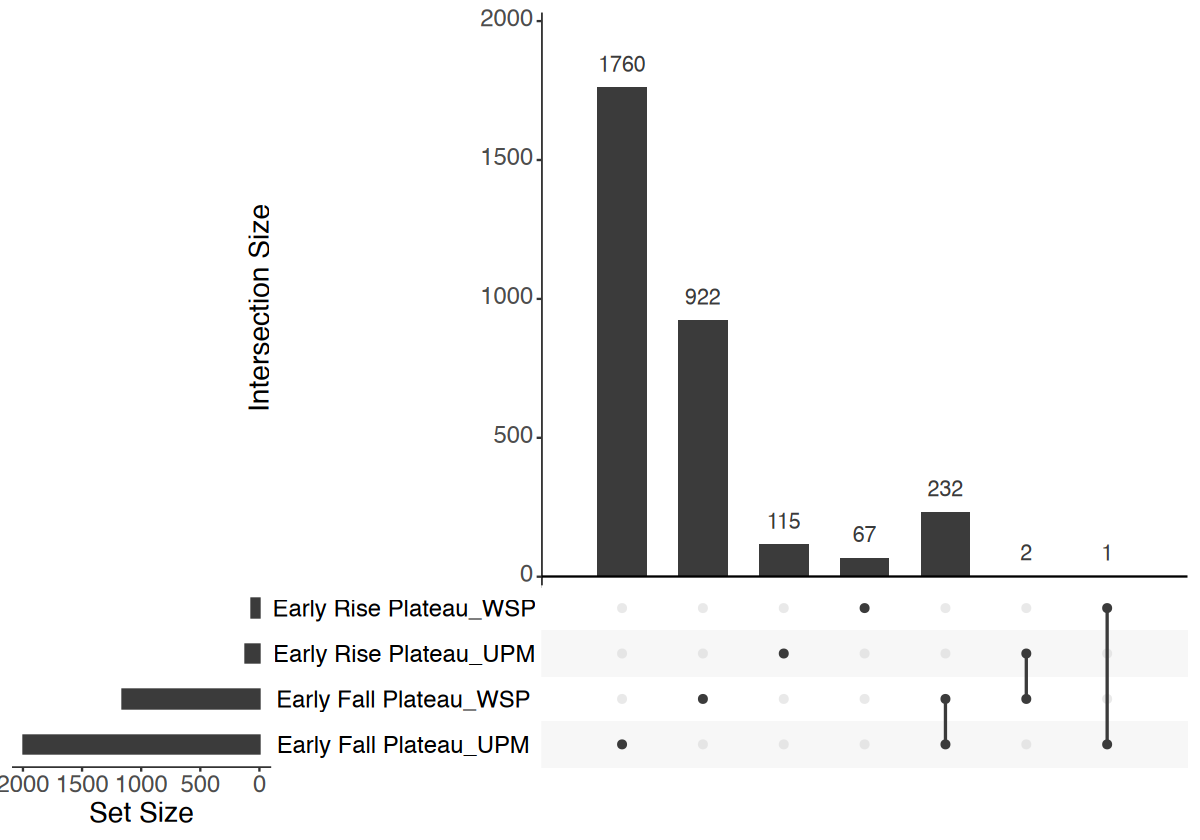

In [53]:
Plateau <- list("Early Fall Plateau_UPM"=UPM_time_sig_nontss$EPF, "Early Rise Plateau_UPM"=UPM_time_sig_nontss$EPR, 
              "Early Fall Plateau_WSP"=WSP_time_sig_nontss$EPF, "Early Rise Plateau_WSP"=WSP_time_sig_nontss$EPR)
options(repr.plot.width=10)
upset(fromList(Plateau), nsets=4, text.scale=2)


[1] "chr3:138625868-138626308" "chr3:31664984-31665636"

[1] "chr5:177402543-177402981" "chr19:40365654-40365918"

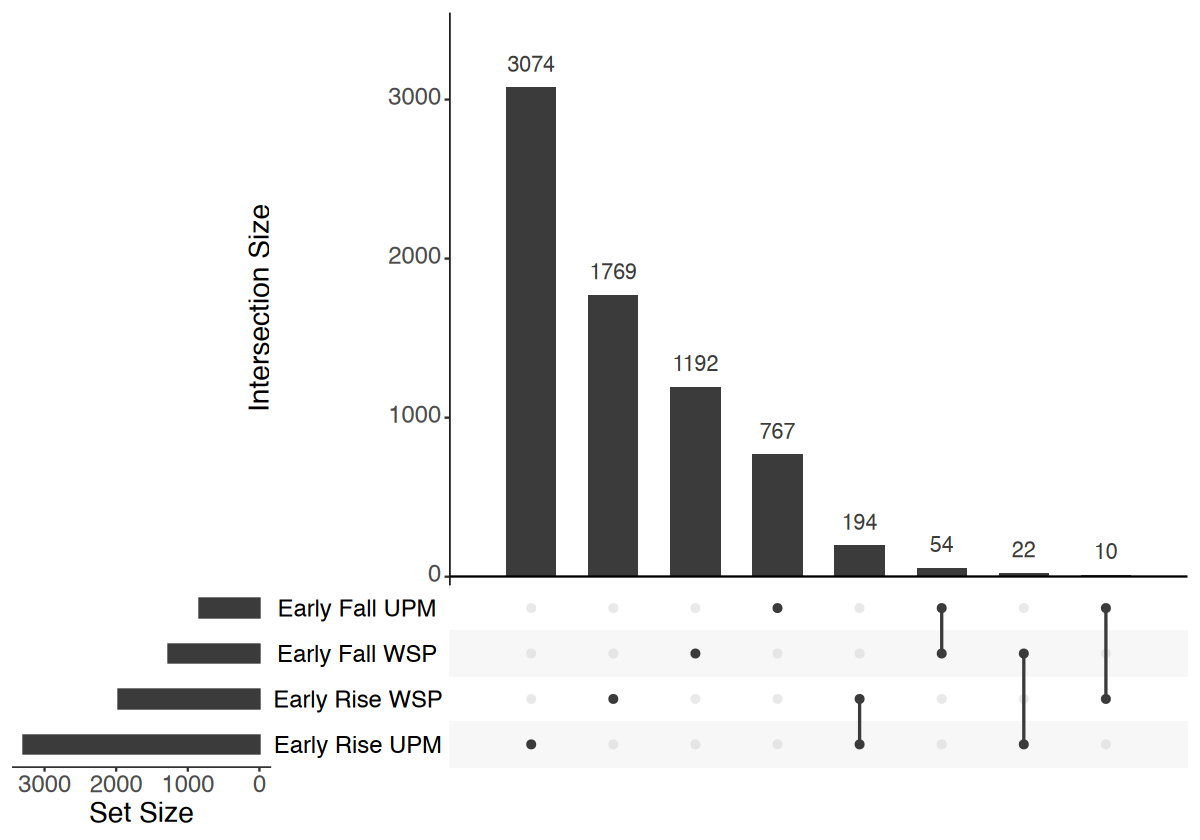

In [54]:
Early <- list("Early Fall UPM"=UPM_time_sig_nontss$EF, "Early Rise UPM"=UPM_time_sig_nontss$ER, 
              "Early Fall WSP"=WSP_time_sig_nontss$EF, "Early Rise WSP"=WSP_time_sig_nontss$ER)
nontss_ER_both = intersect(UPM_time_sig_nontss$ER, 
                           WSP_time_sig_nontss$ER)
nontss_EF_both = intersect(UPM_time_sig_nontss$EF, 
                           WSP_time_sig_nontss$EF)
nontss_ER_both[1:2]
nontss_EF_both[1:2]
options(repr.plot.width=10)
upset(fromList(Early), nsets=4, text.scale=2)

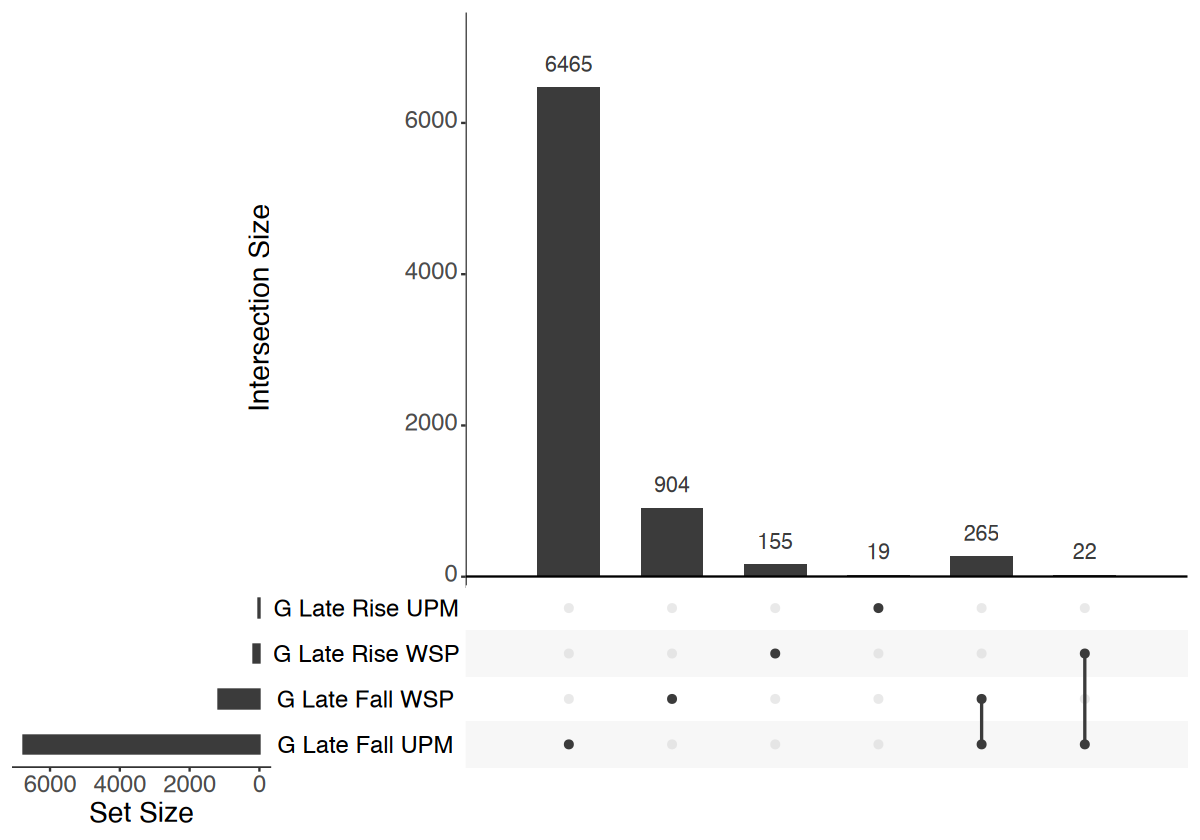

In [55]:
Late <- list("G Late Fall UPM"=UPM_time_sig_nontss$LF, "G Late Rise UPM"=UPM_time_sig_nontss$LR, 
              "G Late Fall WSP"=WSP_time_sig_nontss$LF, "G Late Rise WSP"=WSP_time_sig_nontss$LR)
options(repr.plot.width=10)
upset(fromList(Late), nsets=4, text.scale=2)

#### What TF motifs are enriched in these connections and does it match similarities in TFEA?
1. Get the bed file
2. Get the fasta
3. Upload to Simple Enrichment Analysis (MEME)

In [133]:
get_nontss_bed <- function(nontss_list, filename) {
    split <-  str_split_fixed(nontss_list, ":", 2)
    split2 <- str_split_fixed(split[,2], "-", 2)
    bed <- data.table("Chrom"=split[,1], "start"=split2[,1], "end"=split2[,2], 
                     "name"=nontss_list)
    bed$mu <- as.integer((as.integer(bed$start)+as.integer(bed$end))/2)
    bed$new_start <- bed$mu - 1500
    bed$new_end <- bed$mu + 1500
    dim(bed[bed$new_start < 1,])
    bed[1:2,]
    write.table(bed[,c("Chrom", "new_start", "new_end", "name")], 
                paste0("../results/SEA_input/", filename), 
                quote=FALSE, sep="\t", row.names=FALSE, col.names=FALSE)
    }
get_nontss_bed(nontss_ER_both, "NonTSS_EarlyRise_BOTHWSPUPM.bed")
get_nontss_bed(nontss_EF_both, "NonTSS_EarlyFall_BOTHWSPUPM.bed")